# GARCH(1,1) baseline - silver

Same model as notebook 03, fit to silver's daily returns instead of gold's. See that notebook for the fuller explanations of each step.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

In [2]:
silver = pd.read_csv("../data/silver_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
silver.index.name = "Date"

returns = silver["Close"].pct_change().dropna() * 100
returns.head()

Date
2010-01-05    1.955273
2010-01-06    2.148360
2010-01-07    0.935969
2010-01-08    0.681831
2010-01-11    1.218986
Name: Close, dtype: float64

## Build and fit the model

In [3]:
model = arch_model(returns, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
result = model.fit(disp="off")
print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8530.73
Distribution:                  Normal   AIC:                           17069.5
Method:            Maximum Likelihood   BIC:                           17094.8
                                        No. Observations:                 4170
Date:                Sat, Aug 08 2026   Df Residuals:                     4169
Time:                        16:23:52   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0174  2.686e-02      0.649      0.516 

## Plot fitted volatility vs actual returns

Worth comparing this plot and the alpha/beta values to gold's - given silver's more volatile return series, we'd expect a stronger, more visible reaction pattern.

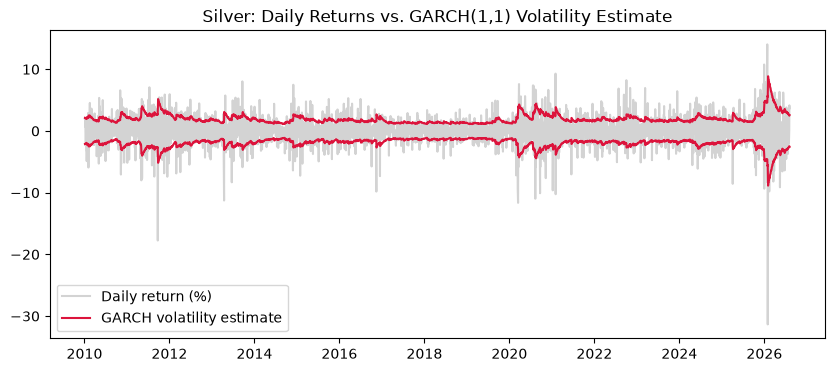

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(returns.index, returns, color="lightgray", label="Daily return (%)")
ax.plot(result.conditional_volatility.index, result.conditional_volatility, color="crimson", label="GARCH volatility estimate")
ax.plot(result.conditional_volatility.index, -result.conditional_volatility, color="crimson")
ax.set_title("Silver: Daily Returns vs. GARCH(1,1) Volatility Estimate")
ax.legend()
plt.show()